# 11 — Biodiesel: observed-interval training (experiment)

Normal training integrates each training trajectory from its initial state over the whole
30 s and scores the complete prediction. Observed-interval training restarts each of the
29 intervals from its observed state and scores only the next endpoint. All interval
gradients accumulate before one Adam update per epoch. Both methods train for 10,000
epochs with the same 156-parameter model, learning rate, solver, and normalized squared-error reduction.

We report both the **local objective actually minimized** and **full-rollout errors** on
training and held-out trajectories. Local comparisons must use the same observed-state
resets for both methods. Full-rollout comparisons start from each initial condition
and continue without resets. Their absolute losses answer different questions.

**Generate the email figures here.** The Figure 3, Figure 5B, and Figure 5A cells call
the existing plotting scripts as Python functions, display the figures inline, and save
PDF/PNG attachments under the experiment's figures directory. No shell commands or
additional training are needed.

Observed-interval training is an additional experiment, not a procedure specified by the
ChemKAN paper. This notebook uses the saved clean-data runs for seeds 0, 1, and 2.


In [1]:
%matplotlib inline

In [2]:
from pathlib import Path
import sys, csv
import numpy as np
import torch
import matplotlib.pyplot as plt

ROOT = Path.cwd()
while not (ROOT / "chemkan" / "src").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
for sub in ("src", "scripts", "scripts/figures"):
    sys.path.insert(0, str(ROOT / "chemkan" / sub))

from chemkan.normalization import MinMaxNormalizer
from evaluate_biodiesel import build_kinetic_core, solver_from_ckpt, integrate_biodiesel
from _data import load_biodiesel, load_input_scaling
from plot_biodiesel_interval_objective import restore_grid_widths

EXP  = ROOT / "results/experiments/biodiesel_observed_intervals"
FIGS = EXP / "figures"
TABS = EXP / "tables"
SEEDS = [0, 1, 2]

# The two runs of a seed start from identical initial weights.
INTERVAL = {s: EXP / f"seed{s}" for s in SEEDS}
ORIGINAL = {
    # Seed 0 is the reproduction's clean run (clean_replay_seed0: a bit-identical re-run
    # of main/direct_autograd_seed0 that also logged the test loss every epoch).
    0: ROOT / "results/reproduction/chemkan/biodiesel/noise/clean_replay_seed0",
    1: EXP / "baseline_original_seed1",
    2: EXP / "baseline_original_seed2",
}

TRAIN, TEST = load_biodiesel("train"), load_biodiesel("test")
species = [str(s) for s in TRAIN["species"]]
print("species:", species)
print(f"train / test trajectories: {TRAIN['Y0'].shape[0]} / {TEST['Y0'].shape[0]}, "
      f"{len(TRAIN['t'])} saved times over {float(TRAIN['t'][-1]):.0f} s")

species: ['TG', 'ROH', 'DG', 'MG', 'GL', 'RCO2R']
train / test trajectories: 20 / 10, 30 saved times over 30 s


## 1. How full-rollout training loss is calculated

“Training” identifies the **20 trajectories being scored**. For an interval-trained
model, this is an evaluation metric, not the loss used for optimizer updates.

At a fixed parameter state:

1. Take each training trajectory's observed initial concentrations and constant temperature.
2. Integrate the learned model once from 0 to 30 s. All later predictions follow the
   model's own evolving state; no intermediate observation resets the solve.
3. Compare predictions at the 30 saved times with the clean observations.
4. Normalize both using the training-set species minima and maxima.
5. Square the errors, average over six species, sum over 30 times, then average over
   20 training trajectories. The initial-time error is zero.

For arrays shaped (30 times, 20 trajectories, 6 species), this is:

```python
squared_error = (normalizer.normalize(prediction) - normalizer.normalize(observations)) ** 2
full_rollout_train_loss = squared_error.mean(dim=2).sum(dim=0).mean()
```

The held-out calculation is identical, but uses the **10 test trajectories** and still
uses training-set normalization. Neither evaluation updates the model.

The **interval objective** instead makes 29 short solves, each starting from its observed
state, and scores only the next endpoint. This is what the interval optimizer minimizes.
For example, the same seed-0 final model has interval objective about 0.0002454,
full-rollout training loss 0.032555, and full-rollout held-out loss 0.085017.

The next cell reevaluates the final checkpoints after 10,000 epochs. For each species,
`sq.sum(dim=0).mean(dim=0)` sums time and averages trajectories; the mean of the six
species gives the same `chemkan.losses.trajectory_mse` reduction. Lower is better.


In [3]:
NORM = MinMaxNormalizer(TRAIN["u_min"], TRAIN["u_max"])      # train-only statistics
DATA = {"train": TRAIN, "test": TEST}
with open(TABS / "observed_intervals_final_comparison.csv", newline="") as f:
    recorded_final = {int(r["seed"]): r for r in csv.DictReader(f)}

@torch.no_grad()
def evaluate(run_dir, split):
    """Per-species full-rollout error of a run's final model on one split -> (6,)."""
    ckpt = torch.load(run_dir / "checkpoint_final.pt", map_location="cpu", weights_only=False)
    core = build_kinetic_core(ckpt, len(species), "cpu")
    restore_grid_widths(core)  # recover legacy widths from the saved centers
    d = DATA[split]
    pred = integrate_biodiesel(core, load_input_scaling(ckpt, "cpu"), solver_from_ckpt(ckpt),
                               d["Y0"], d["T_const"], d["t"])          # (30 times, B, 6)
    sq = (NORM.normalize(pred) - NORM.normalize(d["species_TBm"])) ** 2
    return sq.sum(dim=0).mean(dim=0).numpy()       # sum over time, mean over trajectories

# errors[method, seed, split] = per-species error; its mean is the Eq. 18 loss.
errors = {(method, s, split): evaluate(runs[s], split)
          for method, runs in (("interval", INTERVAL), ("original", ORIGINAL))
          for s in SEEDS for split in ("train", "test")}

rows = []
for s in SEEDS:
    r = {"seed": s}
    for split in ("train", "test"):
        r[f"obs_{split}"] = float(errors["interval", s, split].mean())
        r[f"orig_{split}"] = float(errors["original", s, split].mean())
    for split in ("train", "test"):
        r[f"d_{split}"] = r[f"obs_{split}"] - r[f"orig_{split}"]
    for split in ("train", "test"):
        r[f"ratio_{split}"] = r[f"obs_{split}"] / r[f"orig_{split}"]
    for key in ("obs_train", "orig_train", "obs_test", "orig_test"):
        np.testing.assert_allclose(r[key], float(recorded_final[s][key]), rtol=1e-5, atol=1e-9)
    rows.append(r)

print(f"{'seed':>4} | {'train: interval':>15} {'normal':>8} {'Δ':>9} | "
      f"{'test: interval':>14} {'normal':>8} {'Δ':>9}")
for r in rows:
    print(f"{r['seed']:>4} | {r['obs_train']:>15.5f} {r['orig_train']:>8.5f} {r['d_train']:>+9.5f} | "
          f"{r['obs_test']:>14.5f} {r['orig_test']:>8.5f} {r['d_test']:>+9.5f}")
print(f"\ninterval training better on train in {sum(r['d_train'] < 0 for r in rows)}/3 seeds, "
      f"on test in {sum(r['d_test'] < 0 for r in rows)}/3 seeds")

with open(TABS / "observed_intervals_final_comparison.csv", "w", newline="") as f:
    w = csv.DictWriter(f, fieldnames=list(rows[0]))
    w.writeheader(); w.writerows(rows)

seed | train: interval   normal         Δ | test: interval   normal         Δ
   0 |         0.03255  0.06202  -0.02946 |        0.08502  0.08140  +0.00362
   1 |         0.02325  0.02247  +0.00078 |        0.06733  0.06324  +0.00408
   2 |         0.01814  0.03312  -0.01498 |        0.07055  0.05567  +0.01488

interval training better on train in 2/3 seeds, on test in 0/3 seeds


## 2. Error by species

The same numbers as the table above, split by species and averaged over the three seeds.

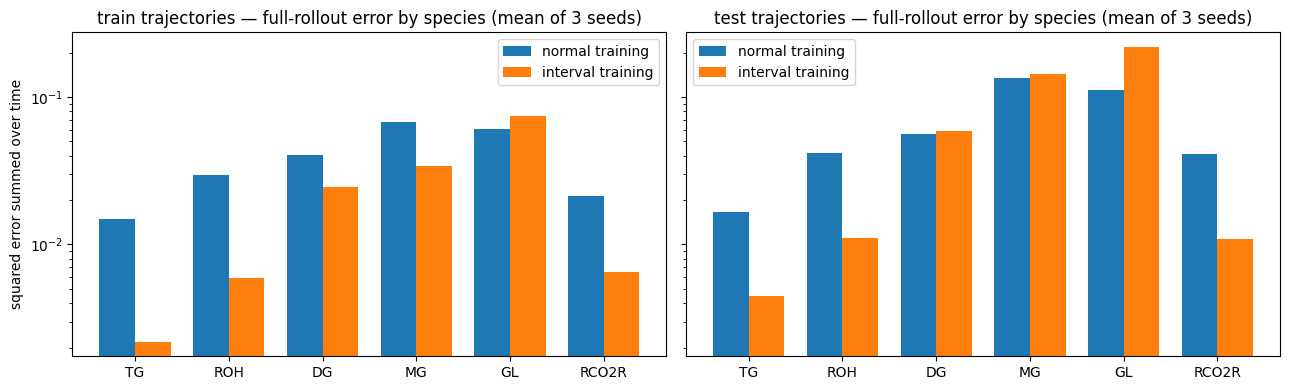

In [4]:
x, width = np.arange(len(species)), 0.38
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
for ax, split in zip(axes, ("train", "test")):
    for offset, method, label in ((-width / 2, "original", "normal training"),
                                  (+width / 2, "interval", "interval training")):
        mean = np.mean([errors[method, s, split] for s in SEEDS], axis=0)
        ax.bar(x + offset, mean, width, label=label)
    ax.set_xticks(x, species)
    ax.set_yscale("log")
    ax.set_title(f"{split} trajectories — full-rollout error by species (mean of 3 seeds)")
    ax.legend()
axes[0].set_ylabel("squared error summed over time")
fig.tight_layout()
fig.savefig(FIGS / "observed_intervals_per_species.pdf")
fig.savefig(FIGS / "observed_intervals_per_species.png", dpi=150)
plt.show()

with open(TABS / "observed_intervals_error_breakdown.csv", "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["split", "seed", "procedure", *[f"species_{sp}" for sp in species], "total"])
    for (method, s, split), v in errors.items():
        name = "observed_interval" if method == "interval" else "original"
        w.writerow([split, s, name, *map(float, v), float(v.mean())])

## 3. Training curves

Both panels show the full-rollout loss recorded **during** training (Eq. 18,
time-summed): solid = interval training, dashed = normal training, one colour per seed.
Interval runs evaluated the full rollout every 100 epochs; normal runs did so every
epoch, which is why their curves look noisier. The loss each run actually minimized is
plotted below.

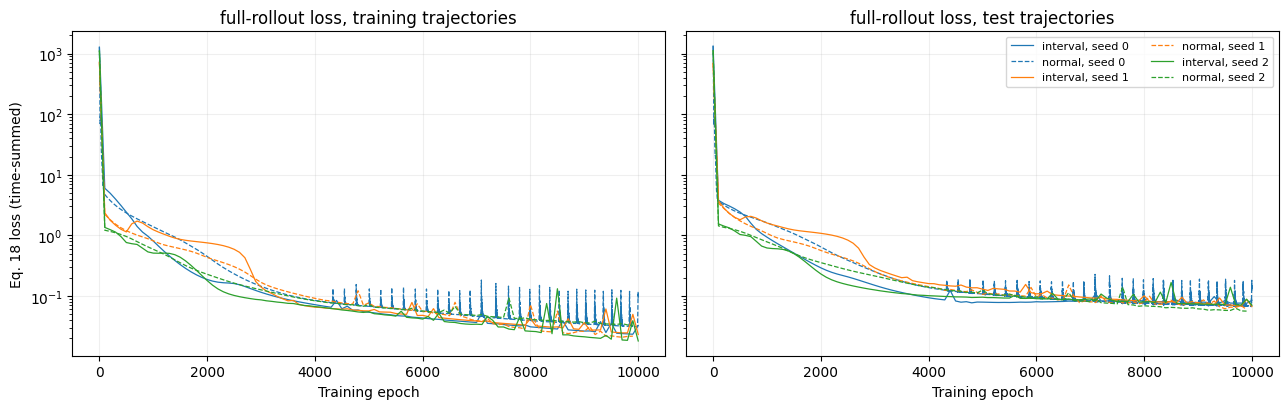

In [5]:
def history(run_dir):
    """(epochs, full-rollout train loss, full-rollout clean test loss) from history.csv."""
    with open(run_dir / "history.csv", newline="") as f:
        rows = list(csv.DictReader(f))
    if "full_rollout_train_mse" in rows[0]:      # interval run: its own columns, every 100 epochs
        train_col, test_col = "full_rollout_train_mse", "full_rollout_test_mse_clean"
    else:                                          # normal run: total_loss IS the full rollout
        train_col, test_col = "total_loss", "test_mse_clean"
    rows = [r for r in rows if r[train_col] and r[test_col]]
    return (np.array([float(r["epoch"]) for r in rows]),
            np.array([float(r[train_col]) for r in rows]),
            np.array([float(r[test_col]) for r in rows]))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), sharey=True)
for s, color in zip(SEEDS, ("tab:blue", "tab:orange", "tab:green")):
    for runs, style, label in ((INTERVAL, "-", "interval"), (ORIGINAL, "--", "normal")):
        e, train, test = history(runs[s])
        axes[0].semilogy(e, train, style, color=color, lw=0.9, label=f"{label}, seed {s}")
        axes[1].semilogy(e, test, style, color=color, lw=0.9, label=f"{label}, seed {s}")
for ax, title in zip(axes, ("training trajectories", "test trajectories")):
    ax.set_title(f"full-rollout loss, {title}")
    ax.set_xlabel("Training epoch")
    ax.grid(alpha=.2)
axes[0].set_ylabel("Eq. 18 loss (time-summed)")
axes[1].legend(fontsize=8, ncol=2)
fig.tight_layout()
fig.savefig(FIGS / "observed_intervals_training_curves.pdf")
fig.savefig(FIGS / "observed_intervals_training_curves.png", dpi=150)
plt.show()

### Training loss

The loss each method actually minimized, at every epoch (`total_loss` in `history.csv`).
For interval training this is the interval objective: every interval starts from the
observed state, so errors cannot build up and its values are much smaller. For normal
training it is the Eq. 18 full-trajectory loss, the same values as the dashed lines in the
left panel above. The two are different quantities, so they are drawn in separate panels.

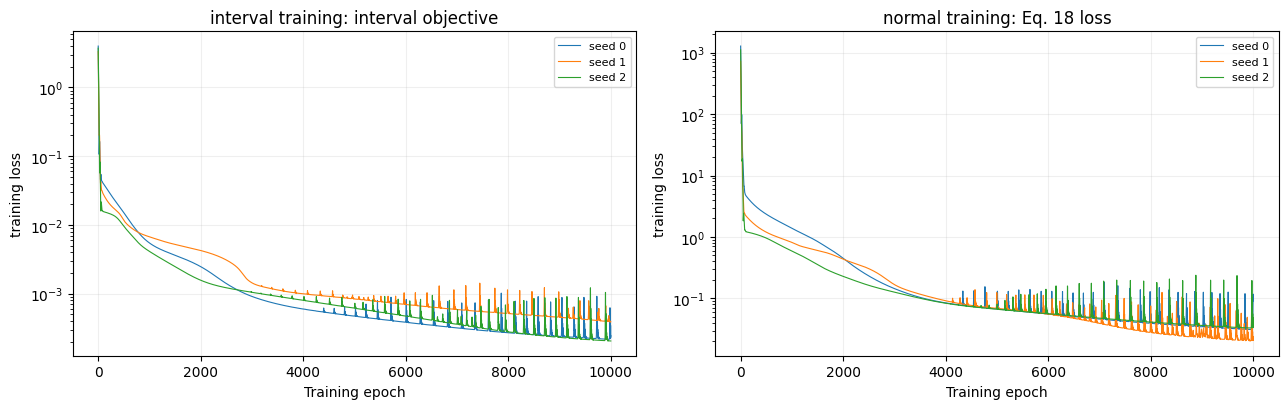

In [6]:
def training_loss(run_dir):
    """(epochs, the loss the run minimized) -- the total_loss column of history.csv."""
    with open(run_dir / "history.csv", newline="") as f:
        rows = list(csv.DictReader(f))
    return (np.array([float(r["epoch"]) for r in rows]),
            np.array([float(r["total_loss"]) for r in rows]))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
for s, color in zip(SEEDS, ("tab:blue", "tab:orange", "tab:green")):
    for ax, runs in ((axes[0], INTERVAL), (axes[1], ORIGINAL)):
        e, loss = training_loss(runs[s])
        ax.semilogy(e, loss, color=color, lw=0.8, label=f"seed {s}")
axes[0].set_title("interval training: interval objective")
axes[1].set_title("normal training: Eq. 18 loss")
for ax in axes:
    ax.set_xlabel("Training epoch")
    ax.set_ylabel("training loss")
    ax.grid(alpha=.2)
    ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIGS / "observed_intervals_training_loss.pdf")
fig.savefig(FIGS / "observed_intervals_training_loss.png", dpi=150)
plt.show()

### Time-averaged diagnostic

The full-rollout Eq. 18 losses from section 1 and the curves above, divided by `N_t`, the
number of time points each loss sums over (the 30 saved times, `t = 0` included). This is
a derived diagnostic, not the paper's Eq. 18 loss. The interval objective is left in its
original form: it sums 29 interval-endpoint errors from restarted solves and is not a
full-rollout Eq. 18 loss.

N_t = 30; values are Eq. 18 loss / N_t

seed | train: interval    normal | test: interval    normal
   0 |       1.085e-03 2.067e-03 |      2.834e-03 2.713e-03
   1 |       7.749e-04 7.489e-04 |      2.244e-03 2.108e-03
   2 |       6.046e-04 1.104e-03 |      2.352e-03 1.856e-03


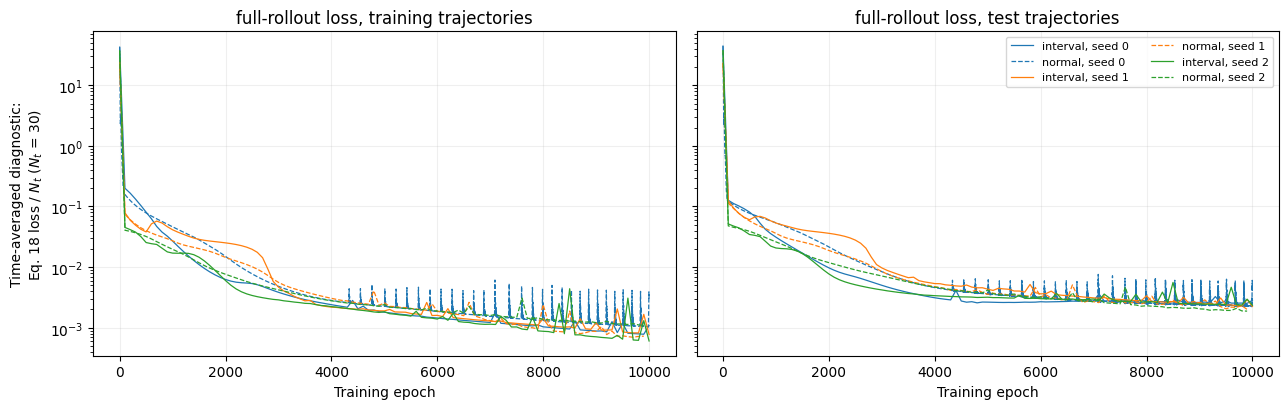

In [7]:
N_T = len(TRAIN["t"])      # time points each full-rollout Eq. 18 loss sums over
print(f"N_t = {N_T}; values are Eq. 18 loss / N_t\n")
print(f"{'seed':>4} | {'train: interval':>15} {'normal':>9} | {'test: interval':>14} {'normal':>9}")
for r in rows:
    print(f"{r['seed']:>4} | {r['obs_train'] / N_T:>15.3e} {r['orig_train'] / N_T:>9.3e} | "
          f"{r['obs_test'] / N_T:>14.3e} {r['orig_test'] / N_T:>9.3e}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), sharey=True)
for s, color in zip(SEEDS, ("tab:blue", "tab:orange", "tab:green")):
    for runs, style, label in ((INTERVAL, "-", "interval"), (ORIGINAL, "--", "normal")):
        e, train, test = history(runs[s])
        axes[0].semilogy(e, train / N_T, style, color=color, lw=0.9, label=f"{label}, seed {s}")
        axes[1].semilogy(e, test / N_T, style, color=color, lw=0.9, label=f"{label}, seed {s}")
for ax, title in zip(axes, ("training trajectories", "test trajectories")):
    ax.set_title(f"full-rollout loss, {title}")
    ax.set_xlabel("Training epoch")
    ax.grid(alpha=.2)
axes[0].set_ylabel(f"Time-averaged diagnostic:\nEq. 18 loss / $N_t$ ($N_t$ = {N_T})")
axes[1].legend(fontsize=8, ncol=2)
fig.tight_layout()
fig.savefig(FIGS / "observed_intervals_training_curves_time_averaged.pdf")
fig.savefig(FIGS / "observed_intervals_training_curves_time_averaged.png", dpi=150)
plt.show()

## 4. Figure 3 — the paper's unseen condition, all four noise columns

TG0 = 1.94, ROH0 = 1.43, other species zero, T = 334.8 K — distinct from both canonical
splits. Six species (rows) × 0 / 5 / 10 / 15 % training noise (columns), one
interval-trained model per column, each 10,000 epochs on the observations at its own
noise level. Every model is integrated from the initial state without intermediate
observations; this is one additional condition, not the aggregate held-out metric.

Two losses per panel: against the **clean** reference, and against the **noisy
observations that column's model was trained on**. Both are the Eq. 18 time-summed loss
with train-only normalization.

The cell reuses `fig03_biodiesel_trajectories.make_figure`, the same function that draws
the reproduction's Figure 3, pointed at the interval runs through its `run_dirs`
argument — nothing about the figure code differs between the methods, only the models. It
saves `figures/fig3_noise_columns.pdf` / `.png` and
`tables/fig3_noise_columns_method_comparison.csv`.

The printed table repeats the clean-reference loss for the original-method models at the
same four levels, so the methods can be read side by side without a second 24-panel grid.
One condition and one seed: the aggregate noise comparison is section 7's Fig. 5A layout.


In [ ]:
# Same figure function as the reproduction's Figure 3, pointed at the interval runs.
from fig03_biodiesel_trajectories import NOISE_LEVELS as FIG3_NOISE_LEVELS, make_figure as make_fig3

interval_noise_runs = {pct: (INTERVAL[0] if pct == 0 else EXP / f"noise/noise{pct:02d}_seed0")
                       for pct in FIG3_NOISE_LEVELS}
for pct, run in interval_noise_runs.items():
    assert (run / "checkpoint_final.pt").exists(), f"{pct}% interval run missing: {run}"

fig3_noise, fig3_noise_results = make_fig3(
    run_dirs=interval_noise_runs, output_path=FIGS / "fig3_noise_columns", show=True)

fig3_original = make_fig3(output_path=None)[1]        # committed original-method runs
print(f"{'noise':>6} | {'interval: vs clean':>18}{'vs its obs':>12} | {'original: vs clean':>19}")
for pct in FIG3_NOISE_LEVELS:
    i, o = fig3_noise_results["levels"][pct], fig3_original["levels"][pct]
    print(f"{pct:>5}% | {i['loss_clean'].mean():>18.5f}{i['loss_obs'].mean():>12.5f} | "
          f"{o['loss_clean'].mean():>19.5f}")
print(f"\nreduction: {fig3_noise_results['reduction']}; one condition, seed 0")

with open(TABS / "fig3_noise_columns_method_comparison.csv", "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["noise_percent", "method", "loss_clean_timesummed", "loss_vs_observations",
                "checkpoint"])
    for pct in FIG3_NOISE_LEVELS:
        for method, res in (("observed_interval", fig3_noise_results), ("original", fig3_original)):
            r = res["levels"][pct]
            w.writerow([pct, method, float(r["loss_clean"].mean()), float(r["loss_obs"].mean()),
                        r["checkpoint"]])


## 5. Clean column at test trajectory 0

The first figure of notebook 07, drawn for the interval-trained seed-0 model: one unseen
test trajectory, dense curve for display, error scored at the 30 observation times.

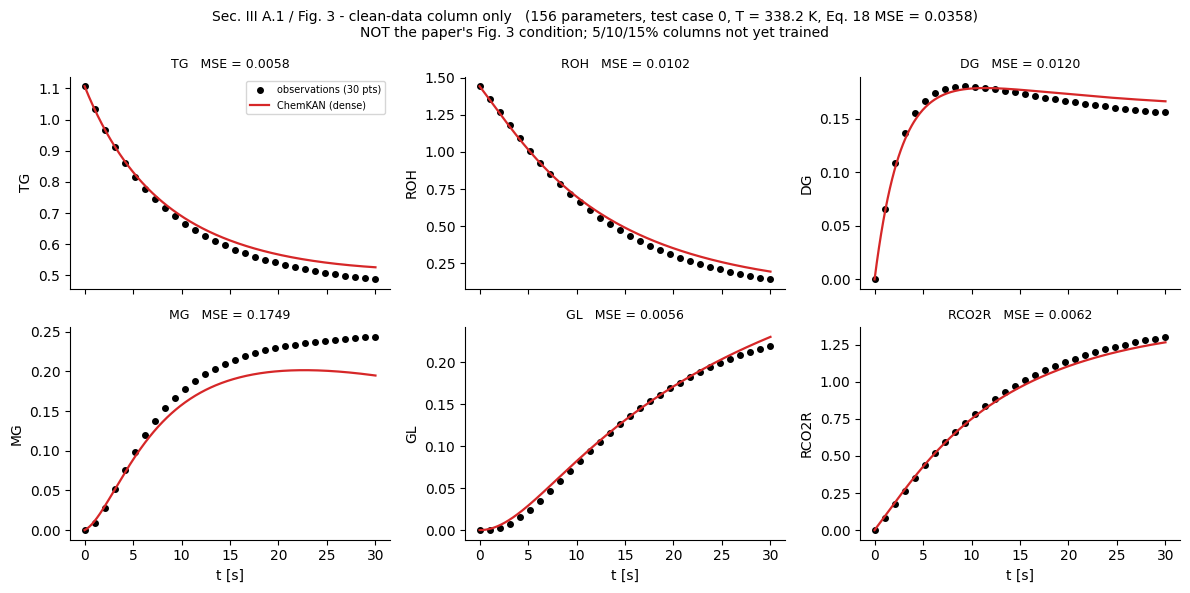

test case 0: Eq. 18 MSE = 0.0358


In [9]:
# Figure code: chemkan/scripts/figures/fig03_biodiesel_trajectories.py
from fig03_biodiesel_trajectories import make_clean_column_figure

_, case0 = make_clean_column_figure(run_dir=INTERVAL[0], case=0, show=True)
print(f"test case 0: Eq. 18 MSE = {case0['case_mse']:.4f}")

## 6. Observed-interval experiment, Fig. 5B layout — interval objective and full-rollout evaluation

**Left:** the interval objective actually minimized, at every epoch, for seeds 0, 1,
and 2. Each short solve starts from its observed state. Its scale is independent of the
full-rollout panel because it scores different predictions.

**Right:** full-rollout training and clean held-out losses for original ChemKAN,
interval-trained ChemKAN, and reference DeepONet, all seed 0. For interval training,
the training-data curve is an evaluation metric, not the optimization objective.
Recorded evaluation times are retained without smoothing or resampling. Separately
identified markers at epoch 10,000 use verified final-checkpoint metrics; the original
training history ends at epoch 9,999 and is not substituted for the final checkpoint.

This is an observed-interval experiment comparison in the layout of the paper's Figure 5B
(0% noise), not a reproduction of that figure.
Tables below the curves show final interval objectives for all three seeds and final
full-rollout training/held-out losses for the three seed-0 models. Values are rounded
for display; the source CSVs retain full precision.

The next cell saves figures/fig5b.pdf and .png and their source CSVs.


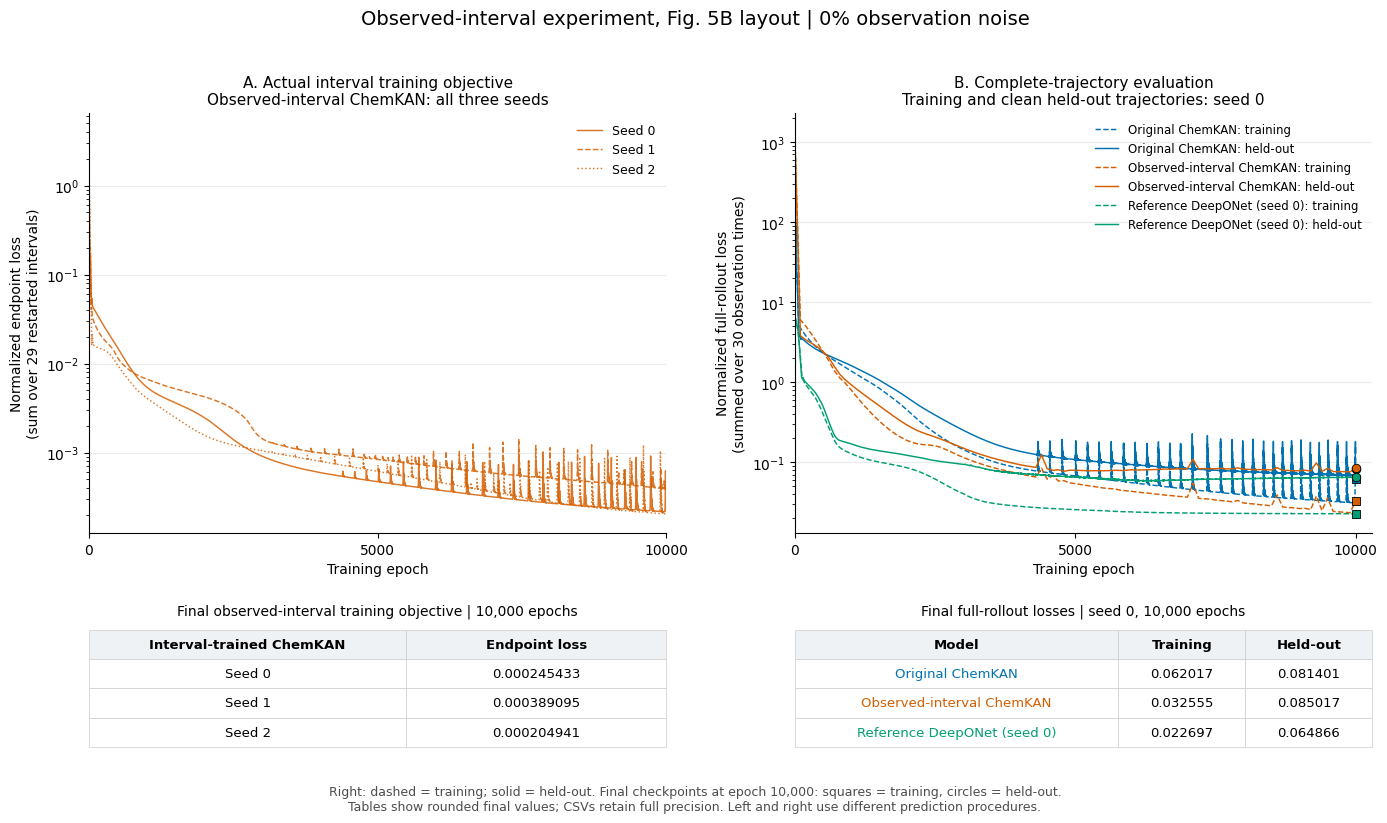

In [10]:
# Reuse the existing Figure 5B script; the two objectives remain separate.
from fig05_biodiesel_loss import make_interval_clean_figure as make_interval_training_figure

fig5b, training_results = make_interval_training_figure(output_path=FIGS / "fig5b", show=True)


### Fig. 5B-layout comparison — full-rollout loss divided by N_t

This companion divides the right-hand full-rollout curves, final markers, and final-loss
table by **N_t = 30**, read from the saved observation grid. This is the mean loss over
the 30 saved times, including the zero initial-time error.

The left-hand interval objective is unchanged: it sums errors over **29 independently
restarted endpoints**. It remains the objective used during interval training, not a
full-rollout metric. Original figures and source tables are preserved.


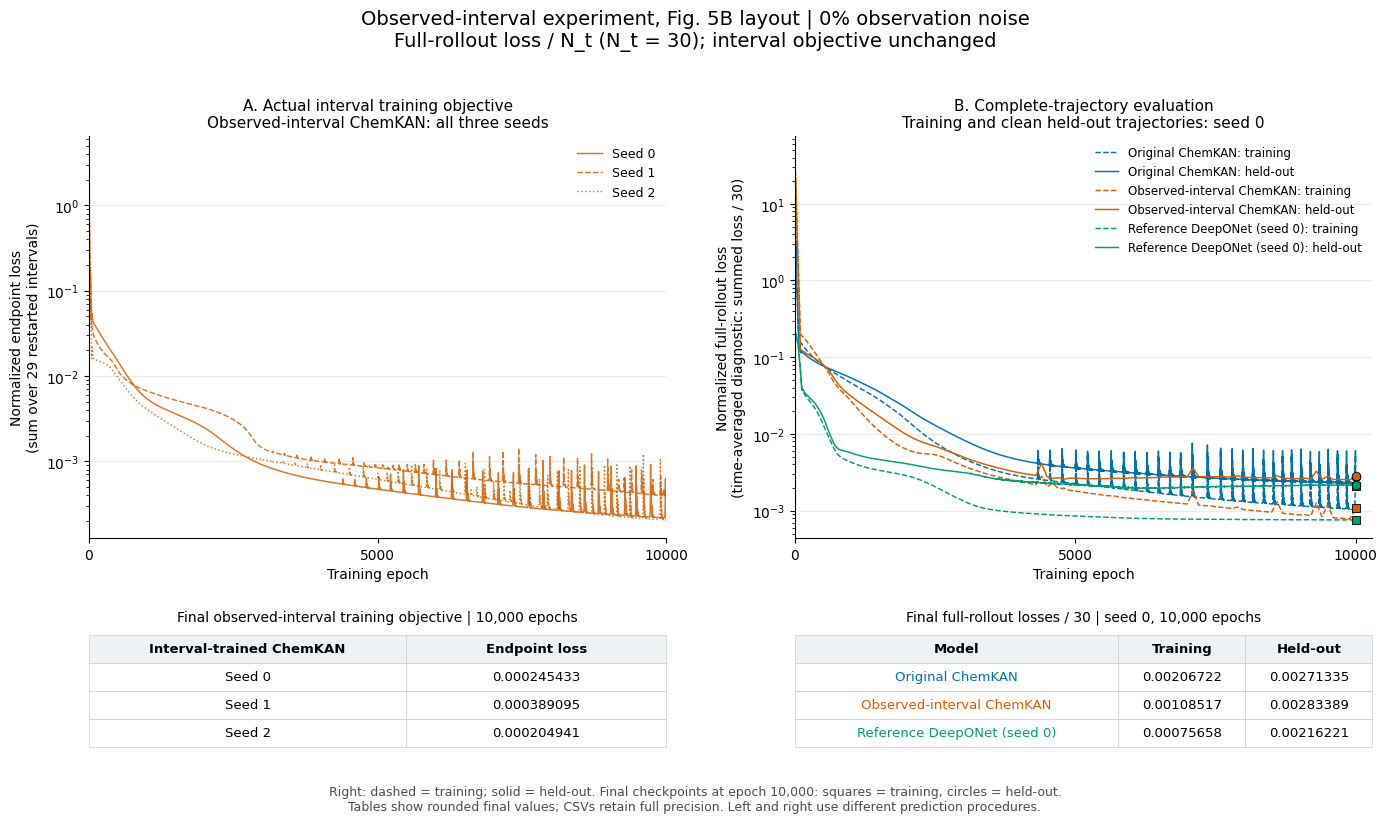

Full-rollout display divisor: N_t = 30; interval objective unchanged.


In [11]:
from fig05_biodiesel_loss import make_interval_clean_figure as make_interval_training_figure

fig5b_time_averaged, training_time_averaged = make_interval_training_figure(
    output_path=FIGS / "fig5b_time_averaged", time_averaged=True, show=True)
print(f"Full-rollout display divisor: N_t = {training_time_averaged['n_times']}; interval objective unchanged.")


## 7. Observed-interval experiment, Fig. 5A layout — final full-rollout losses at 0% noise

Final losses after 10,000 epochs: original and interval-trained ChemKAN for
all three paired seeds, plus reference DeepONet seed 0. Every point corresponds to
**0% observation noise**. The x-axis names the methods; seeds of the same method
share one x coordinate. Point labels give final losses to six decimal places.

The two panels score training and held-out trajectories respectively. Clean and
noisy-reference test metrics coincide at 0%, so only one test metric is shown. This
single noise level compares clean-data performance and does not establish noise robustness.
It is an experiment comparison in the layout of the paper's Figure 5A, not a reproduction
of that figure.

The existing Figure 5A script reads the verified final metric tables, displays the plot,
and writes figures/fig5a.pdf, .png, and tables/fig5a_clean_final_losses.csv.


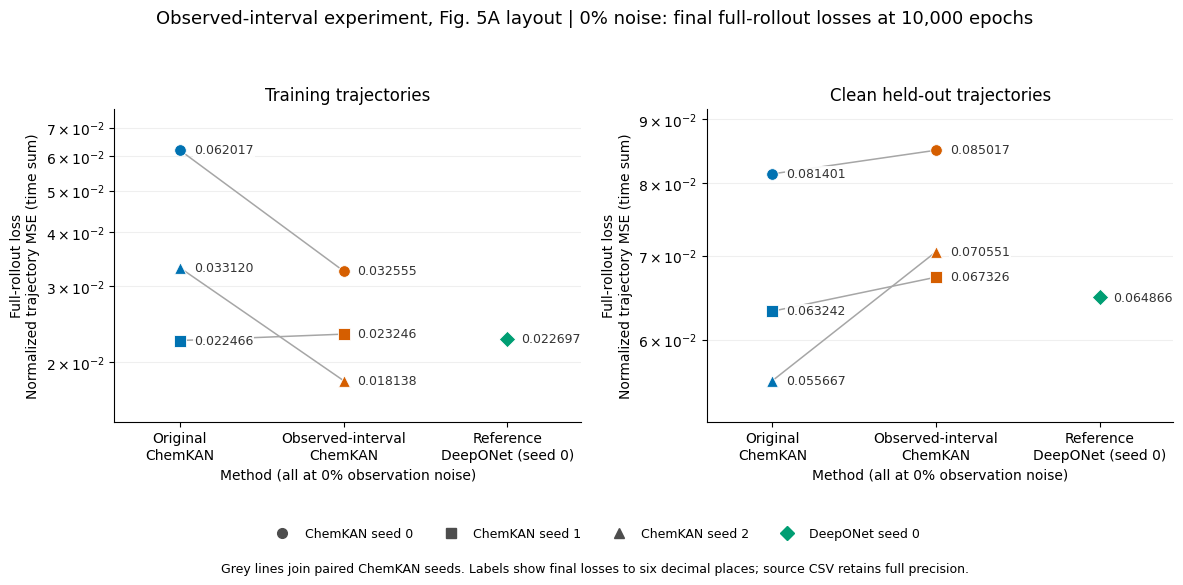

In [12]:
# Reuse the existing Figure 5A script; final metrics include all three paired seeds.
from fig05_biodiesel_noise import make_interval_clean_figure as make_interval_final_figure

fig5a, final_results = make_interval_final_figure(output_path=FIGS / "fig5a", show=True)


### Fig. 5A-layout comparison — full-rollout loss divided by N_t

Both panels, including all point labels, show the final full-rollout loss divided by
**N_t = 30**. This rescales the training and held-out errors uniformly; all method
rankings and relative differences are unchanged. Labels show eight decimal places,
and the companion CSV records both raw and displayed values.

This figure is saved separately from the time-summed Figure 5A.


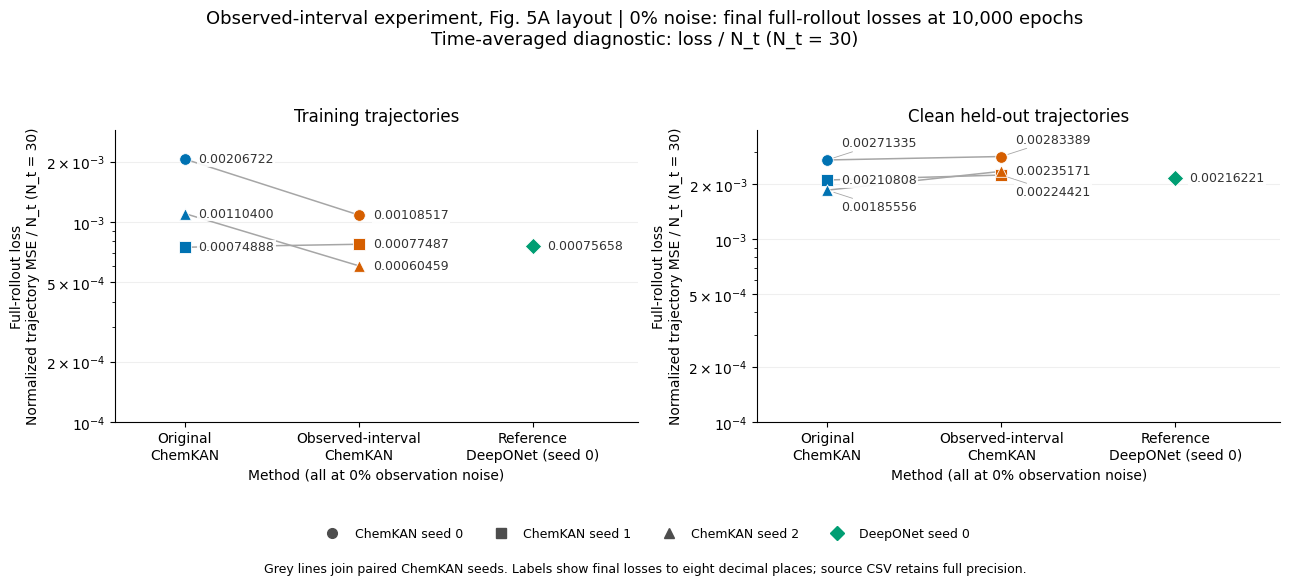

All full-rollout values divided by N_t = 30.


In [13]:
from fig05_biodiesel_noise import make_interval_clean_figure as make_interval_final_figure

fig5a_time_averaged, final_time_averaged = make_interval_final_figure(
    output_path=FIGS / "fig5a_time_averaged", time_averaged=True, show=True)
print(f"All full-rollout values divided by N_t = {final_time_averaged['n_times']}.")


## 8. Comparison with the other clean seed-0 runs

These numbers come from each run's own `history.csv`, not from reloading checkpoints: the
KAN-ODE-kernel run does not record its kernel in the checkpoint, so reloading it with
today's code would silently use the paper kernel. Because the loss oscillates strongly from
epoch to epoch, each value is the **median over the last 20 % of training** (epochs
8,000–10,000).

In [14]:
OTHER_RUNS = {
    "normal training":    ORIGINAL[0],
    "interval training":  INTERVAL[0],
    "Xavier init":        ROOT / "results/experiments/biodiesel_xavier_init/clean_seed0",
    "KAN-ODE RBF kernel": ROOT / "results/experiments/biodiesel_rbf_kanode/clean_seed0",
}

print(f"{'seed 0, clean data':<20}{'train':>9}{'test':>9}")
for name, run in OTHER_RUNS.items():
    e, train, test = history(run)
    late = e >= 8000
    print(f"{name:<20}{np.median(train[late]):>9.4f}{np.median(test[late]):>9.4f}")

seed 0, clean data      train     test
normal training        0.0358   0.0731
interval training      0.0277   0.0796
Xavier init            0.0661   0.1009
KAN-ODE RBF kernel     0.0182   0.0414


## 9. Runtime

Wall time of each paired run, from `history.csv`. `elapsed_seconds` restarts at zero when
a run is resumed, so the segments are added up. For seed 0 the original run's own record is
`main/direct_autograd_seed0` (`clean_replay_seed0`, used above, is its re-run). The runs
shared one machine with up to five concurrent processes, so this is not a clean benchmark.

In [15]:
MAIN0 = ROOT / "results/reproduction/chemkan/biodiesel/main/direct_autograd_seed0"

def wall_time(run_dir):
    # (total wall seconds, number of segments) from history.csv
    with open(run_dir / "history.csv", newline="") as f:
        t = [float(r["elapsed_seconds"]) for r in csv.DictReader(f)]
    ends = [a for a, b in zip(t, t[1:]) if b < a] + [t[-1]]    # last value of each segment
    return sum(ends), len(ends)

runtime = []
for s in SEEDS:
    for name, run in (("observed_interval", INTERVAL[s]),
                      ("original", MAIN0 if s == 0 else ORIGINAL[s])):
        seconds, segments = wall_time(run)
        runtime.append({"seed": s, "procedure": name, "wall_seconds": seconds,
                        "segments": segments,
                        "solver_calls_per_update": 29 if name == "observed_interval" else 1})
        print(f"seed {s}  {name:<18}{seconds:>8.1f} s  ({seconds / 3600:.2f} h, "
              f"{segments} segment{'s' if segments > 1 else ''})")

with open(TABS / "observed_intervals_runtime.csv", "w", newline="") as f:
    w = csv.DictWriter(f, fieldnames=list(runtime[0]))
    w.writeheader(); w.writerows(runtime)

seed 0  observed_interval   5493.2 s  (1.53 h, 1 segment)
seed 0  original             628.1 s  (0.17 h, 1 segment)
seed 1  observed_interval   6768.6 s  (1.88 h, 2 segments)
seed 1  original            1072.6 s  (0.30 h, 1 segment)
seed 2  observed_interval   6528.6 s  (1.81 h, 2 segments)
seed 2  original            1084.6 s  (0.30 h, 1 segment)


## 10. Fig. 5B layout across noise levels (0 / 2 / 7 / 15 %) — status view

Seed 0 per panel: original ChemKAN (normal training, every epoch) and observed-interval
ChemKAN (full-trajectory evaluation every 100 epochs). Dashed = training loss against the
**noisy** observations the run saw; solid = noise-free test loss (Eq. 22). Both are the
time-summed Eq. 18 full-trajectory loss; the interval objective is not shown here.

Interval noise runs live in `noise/noiseNN_seed0/`; all four levels shown here are
finished. The cell still degrades gracefully: a level whose `history.csv` is missing
appears as an empty panel, and a run still training is plotted up to its last evaluation
and marked *in progress*.

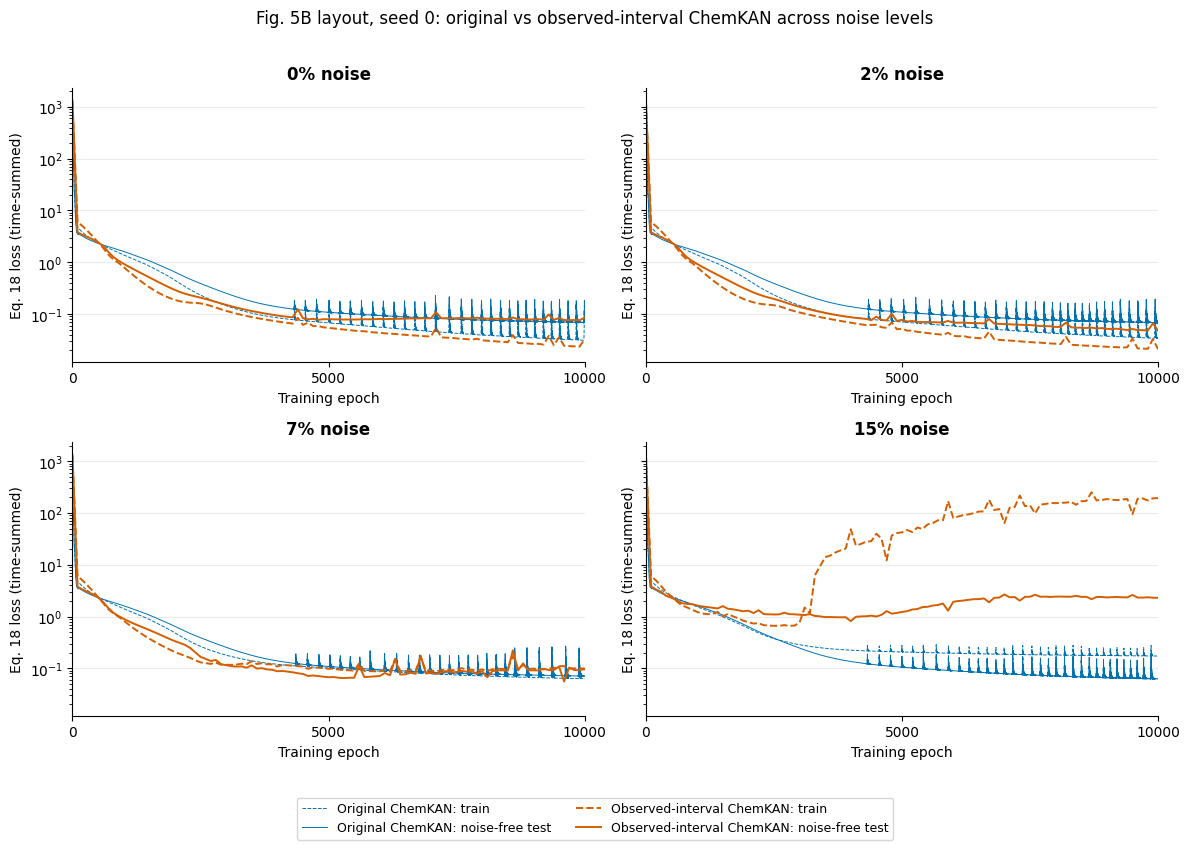

noise  interval run               last train last clean test
   0%  finished                       0.0326          0.0850
   2%  finished                       0.0208          0.0478
   7%  finished                       0.0997          0.0961
  15%  finished                     194.1049          2.2977


In [16]:
from fig05_biodiesel_loss import NOISE_LEVELS, default_chemkan_run, load_history
from fig05_biodiesel_noise import INTERVAL_MODEL_COLORS, INTERVAL_MODEL_LABELS


def interval_noise_run(pct):
    return INTERVAL[0] if pct == 0 else EXP / f"noise/noise{pct:02d}_seed0"


def interval_history(run_dir):
    """(epochs, full-trajectory train loss vs the run's observations, clean test loss), status."""
    with open(run_dir / "history.csv", newline="") as f:
        rows = list(csv.DictReader(f))
    last = int(float(rows[-1]["epoch"]))
    done = (run_dir / "checkpoint_final.pt").exists()
    rows = [r for r in rows if r["full_rollout_train_mse"] and r["full_rollout_test_mse_clean"]]
    e = np.array([float(r["epoch"]) for r in rows])
    return (e, np.array([float(r["full_rollout_train_mse"]) for r in rows]),
            np.array([float(r["full_rollout_test_mse_clean"]) for r in rows]),
            "finished" if done else f"in progress, epoch {last}")


fig, axes = plt.subplots(2, 2, figsize=(12, 8.5), sharey=True)
status = []
for ax, pct in zip(axes.flat, NOISE_LEVELS):
    e, train, test = load_history(default_chemkan_run(pct))
    c = INTERVAL_MODEL_COLORS["original"]
    ax.plot(e, train, color=c, ls="--", lw=0.7, label=f'{INTERVAL_MODEL_LABELS["original"]}: train')
    ax.plot(e, test, color=c, lw=0.7, label=f'{INTERVAL_MODEL_LABELS["original"]}: noise-free test')
    run = interval_noise_run(pct)
    title = f"{pct}% noise"
    if (run / "history.csv").exists():
        e, train, test, state = interval_history(run)
        c = INTERVAL_MODEL_COLORS["observed_interval"]
        ax.plot(e, train, color=c, ls="--", lw=1.4, label=f'{INTERVAL_MODEL_LABELS["observed_interval"]}: train')
        ax.plot(e, test, color=c, lw=1.4, label=f'{INTERVAL_MODEL_LABELS["observed_interval"]}: noise-free test')
        status.append((pct, state, train[-1], test[-1]))
        if state != "finished":
            title += f"  ({state})"
    else:
        ax.text(0.5, 0.5, "interval run not available here", transform=ax.transAxes,
                ha="center", va="center", color="0.4")
        status.append((pct, "missing", np.nan, np.nan))
    ax.set_title(title, fontweight="bold")
    ax.set_yscale("log"); ax.set_xlim(0, 10000); ax.set_xticks([0, 5000, 10000])
    ax.set_xlabel("Training epoch"); ax.set_ylabel("Eq. 18 loss (time-summed)")
    ax.grid(axis="y", alpha=0.25)
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, ncol=2, loc="lower center", fontsize=9)
fig.suptitle("Fig. 5B layout, seed 0: original vs observed-interval ChemKAN across noise levels")
fig.tight_layout(rect=(0, 0.08, 1, 0.97))
plt.show()

print(f"{'noise':>5}  {'interval run':<26}{'last train':>11}{'last clean test':>16}")
for pct, state, tr, te in status:
    print(f"{pct:>4}%  {state:<26}{tr:>11.4f}{te:>16.4f}")

## 11. Figure 4 layout — width scaling, original vs observed-interval training

Side-by-side neural scaling: the same ChemKAN widths trained with the two methods and
evaluated with the same metric.

**Held identical between the panels.** Widths `h = 2, 3, 4, 10, 17` with
`n_mu = ceil(h/2)`, `N = 3`, base OFF, seed 0, Adam lr = 2e-3, Tsit5 (rtol 1e-6,
atol 1e-8), **5,000 updates**, 0 % noise — the matrix in `docs/fig4_width_matrix.md`.
Parameter counts are measured from the checkpoints (`P(h) = 39h`), never assumed. Both
panels report the Eq. 18 time-summed full-rollout loss from `evaluate_biodiesel`, the
same function the published Figure 4 uses, so the methods are compared on the same
quantity — **not** on the interval objective, which scores restarted endpoints and is not
comparable across methods.

**Only the training procedure differs.** Left: the original trainer, one trajectory
integrated from `t = 0` to `t_end` and scored against the whole observation sequence.
Right: observed-interval training, every interval restarted from its observed state.
DeepONet appears on the left only, as in the paper's figure — it was never trained with
the interval procedure — and the left ChemKAN curve is repeated faintly on the right for
reference.

**`h = 4` is not retrained on either side.** Both methods reuse their seed-0 run's
5,000-update snapshot (`checkpoint_epoch_5000.pt`), which carries every Figure-4 setting.
The same documented wart applies to both: the snapshot's epoch marker sits under the key
`stage2_epoch` because the helper is shared with hydrogen Stage 2. The value is correct
and the cell asserts it.

Original-method points are read from
`results/reproduction/tables/biodiesel_fig4_points.csv` (written by
`chemkan/scripts/figures/fig04_biodiesel_scaling.py`); interval points are evaluated here
from the run checkpoints. All five widths are present. The cell still degrades
gracefully: a width whose interval run is missing is listed under the table and left out
of the plot, never interpolated.

**No regression line is drawn.** The published figure fits one, but both methods are
non-monotonic in parameter count here, so a slope would describe the fit rather than the
data; the comparison is point-by-point. The `n_mu = 2` diagnostic variant of the original sweep is not shown.


In [ ]:
# Original-method points: chemkan/scripts/figures/fig04_biodiesel_scaling.py
from evaluate_biodiesel import evaluate_biodiesel

FIG4_WIDTHS = {2: 1, 3: 2, 4: 2, 10: 5, 17: 9}     # h -> n_mu = ceil(h/2)
FIG4_EPOCHS = 5000                                  # the Figure-4 budget on both sides


def interval_checkpoint(h):
    """Interval-run checkpoint for width h; h=4 reuses the seed-0 5,000-update snapshot."""
    if h == 4:
        return INTERVAL[0] / "checkpoint_epoch_5000.pt"
    return EXP / f"scaling/h{h:02d}_seed0" / "checkpoint_final.pt"


def interval_point(h, n_mu):
    """Eq. 18 full-rollout train/test loss of one interval width, with its settings verified."""
    path = interval_checkpoint(h)
    ckpt = torch.load(path, map_location="cpu", weights_only=False)
    arch = ckpt["architecture"]
    assert arch["n_mu"] == n_mu, f"h={h}: n_mu {arch['n_mu']} != {n_mu}"
    assert arch["hidden_dim"] == h and arch["num_basis"] == 3 and not arch["use_base_act"]
    epochs = ckpt.get("stage2_epoch") or ckpt["training"]["epochs"]   # snapshot marker for h=4
    assert epochs == FIG4_EPOCHS, f"h={h}: {epochs} updates, not {FIG4_EPOCHS}"
    train, test = (evaluate_biodiesel(str(path), split, "cpu") for split in ("train", "test"))
    return {"width": h, "n_mu": n_mu, "parameters": train["n_params"],
            "train_loss": train["mse"], "test_loss": test["mse"],
            "reused": h == 4, "source": str(path.relative_to(ROOT))}


interval_pts, missing = [], []
for h, n_mu in FIG4_WIDTHS.items():
    if interval_checkpoint(h).exists():
        interval_pts.append(interval_point(h, n_mu))
    else:
        missing.append(h)
interval_pts.sort(key=lambda p: p["parameters"])

with open(ROOT / "results/reproduction/tables/biodiesel_fig4_points.csv", newline="") as f:
    original_rows = list(csv.DictReader(f))
orig = {m: sorted(({"width": int(r["width"]), "parameters": int(r["parameters"]),
                    "train_loss": float(r["train_loss"]), "test_loss": float(r["test_loss"])}
                   for r in original_rows if r["model"] == m), key=lambda p: p["parameters"])
        for m in ("ChemKAN", "DeepONet")}

P = lambda pts: [p["parameters"] for p in pts]
L = lambda pts, key: [p[key] for p in pts]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharex=True, sharey=True)
for ax, (title, pts) in zip(axes, (("original training (full trajectory)", orig["ChemKAN"]),
                                   ("observed-interval training", interval_pts))):
    if ax is axes[1]:      # reference: the left panel's ChemKAN curve, faint
        ax.plot(P(orig["ChemKAN"]), L(orig["ChemKAN"], "train_loss"), "o-", color="0.75",
                ms=4, lw=1, label="ChemKAN train (original method)")
        ax.plot(P(orig["ChemKAN"]), L(orig["ChemKAN"], "test_loss"), "s--", color="0.75",
                ms=4, lw=1, mfc="none", label="ChemKAN test (original method)")
    if pts:
        ax.plot(P(pts), L(pts, "train_loss"), "o-", color="tab:blue", label="ChemKAN train")
        ax.plot(P(pts), L(pts, "test_loss"), "s--", color="tab:blue", mfc="none",
                label="ChemKAN test")
        for p in pts:
            ax.annotate(f"h={p['width']}", (p["parameters"], p["test_loss"]),
                        textcoords="offset points", xytext=(4, 5), fontsize=8, color="0.3")
    if ax is axes[0]:
        ax.plot(P(orig["DeepONet"]), L(orig["DeepONet"], "train_loss"), "o-",
                color="tab:red", label="DeepONet train")
        ax.plot(P(orig["DeepONet"]), L(orig["DeepONet"], "test_loss"), "s--",
                color="tab:red", mfc="none", label="DeepONet test")
    ax.set_title(f"{title}  ({len(missing)} width(s) still missing)" if ax is axes[1] and missing
                 else title, fontweight="bold")
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel("Trainable parameters"); ax.grid(alpha=.25, which="both")
    ax.legend(fontsize=8)
axes[0].set_ylabel("Eq. 18 full-rollout loss (time-summed)")
fig.suptitle("Figure 4 layout, seed 0, 5,000 updates: width scaling under the two training methods")
fig.tight_layout(rect=(0, 0, 1, 0.96))
fig.savefig(FIGS / "fig4_method_comparison.pdf")
fig.savefig(FIGS / "fig4_method_comparison.png", dpi=150)
plt.show()

by_params = {p["parameters"]: p for p in orig["ChemKAN"]}
print(f"{'h':>3}{'n_mu':>5}{'P':>6} | {'original train':>15}{'test':>9} | "
      f"{'interval train':>15}{'test':>9}")
for p in interval_pts:
    o = by_params.get(p["parameters"], {})
    print(f"{p['width']:>3}{p['n_mu']:>5}{p['parameters']:>6} | "
          f"{o.get('train_loss', float('nan')):>15.5f}{o.get('test_loss', float('nan')):>9.5f} | "
          f"{p['train_loss']:>15.5f}{p['test_loss']:>9.5f}"
          + ("   (h=4 reused snapshot)" if p["reused"] else ""))
if missing:
    print("\ninterval runs not present yet: "
          + ", ".join(f"h={h} -> {interval_checkpoint(h).parent.relative_to(ROOT)}" for h in missing))

with open(TABS / "fig4_method_comparison.csv", "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["method", "model", "width", "n_mu", "parameters", "train_loss", "test_loss",
                "reused", "source"])
    for p in interval_pts:
        w.writerow(["observed_interval", "ChemKAN", p["width"], p["n_mu"], p["parameters"],
                    p["train_loss"], p["test_loss"], p["reused"], p["source"]])
    for r in original_rows:
        w.writerow(["original", r["model"], r["width"], r["n_mu"], r["parameters"],
                    r["train_loss"], r["test_loss"], r["reused"], r["source"]])


## Interpretation

**Mixed full-trajectory training results; higher held-out error.** Interval training
lowers the full-rollout training loss in seeds 0 and 2 (0.062 → 0.033 and 0.033 → 0.018)
and raises it in seed 1 (0.0225 → 0.0232, +3.5 %). The held-out loss is **higher in all
three seeds** (+4 %, +6 %, +27 %). This is limited to these three clean-data runs after
10,000 epochs.

**Where the test error goes (section 2).** On test trajectories interval training is about
4× better on TG, ROH and RCO2R, about equal on DG and MG, and about 2× worse on glycerol
(GL). GL and MG carry the largest test errors and account for most of the total.

**Against the other clean seed-0 runs (section 8)**, interval training (test 0.080) and
Xavier initialization (0.101) do not beat normal training (0.073). The KAN-ODE RBF kernel
is the only change so far that clearly lowers the test loss (0.041).

**It is much slower (section 9).** 1.5–1.9 h per run against 0.2–0.3 h for normal
training (6–9×), because every epoch does 29 short solves instead of one long one.

Full-rollout losses sum over the 30 saved times. The separately labelled interval
objective sums errors over 29 independently restarted endpoints. Both average over
species and trajectories using training-set normalization.

## Email attachments

The figure cells above generate these PDFs from the saved runs:

- [Figure 3 — the paper's stated condition, 0/5/10/15 % noise columns](../../results/experiments/biodiesel_observed_intervals/figures/fig3_noise_columns.pdf)
- [Observed-interval experiment, Fig. 5B layout — interval objective and full-rollout training/test dynamics](../../results/experiments/biodiesel_observed_intervals/figures/fig5b.pdf)
- [Observed-interval experiment, Fig. 5A layout — final training/test comparison at 0% noise](../../results/experiments/biodiesel_observed_intervals/figures/fig5a.pdf)

Interpretation for the email: **Full-rollout training error improves in two of the three
seeds, while held-out error is higher in all three. The attached figures show the
training dynamics and final comparison.** The single-condition Figure 3 example does
not replace the aggregate held-out evaluation.

Time-averaged companions (full-rollout loss divided by N_t = 30):

- [Fig. 5B-layout comparison / N_t](../../results/experiments/biodiesel_observed_intervals/figures/fig5b_time_averaged.pdf)
- [Fig. 5A-layout comparison / N_t](../../results/experiments/biodiesel_observed_intervals/figures/fig5a_time_averaged.pdf)

The Fig. 5B-layout comparison retains the actual summed interval objective in its left panel.
